In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = '/content/캡3처.PNG'

original_image = cv2.imread(image_path)

if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    print(f"Image '{image_path}' loaded successfully.")
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    print("Image converted to grayscale successfully.")

Image '/content/캡3처.PNG' loaded successfully.
Image converted to grayscale successfully.


In [ ]:
ret, global_thresholded_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
print("Global thresholding applied successfully.")

Global thresholding applied successfully.


In [ ]:
adaptive_thresholded_image = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
print("Adaptive thresholding applied successfully.")

Adaptive thresholding applied successfully.


In [ ]:
ret_otsu, otsu_thresholded_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu's thresholding applied successfully with threshold value: {ret_otsu}")

Otsu's thresholding applied successfully with threshold value: 91.0


In [ ]:
from skimage.filters import threshold_minimum

min_error_threshold = threshold_minimum(gray_image)
ret_min_error, min_error_thresholded_image = cv2.threshold(gray_image, min_error_threshold, 255, cv2.THRESH_BINARY)
print(f"Minimum Error Thresholding applied successfully with threshold value: {ret_min_error}")

Minimum Error Thresholding applied successfully with threshold value: 213.0


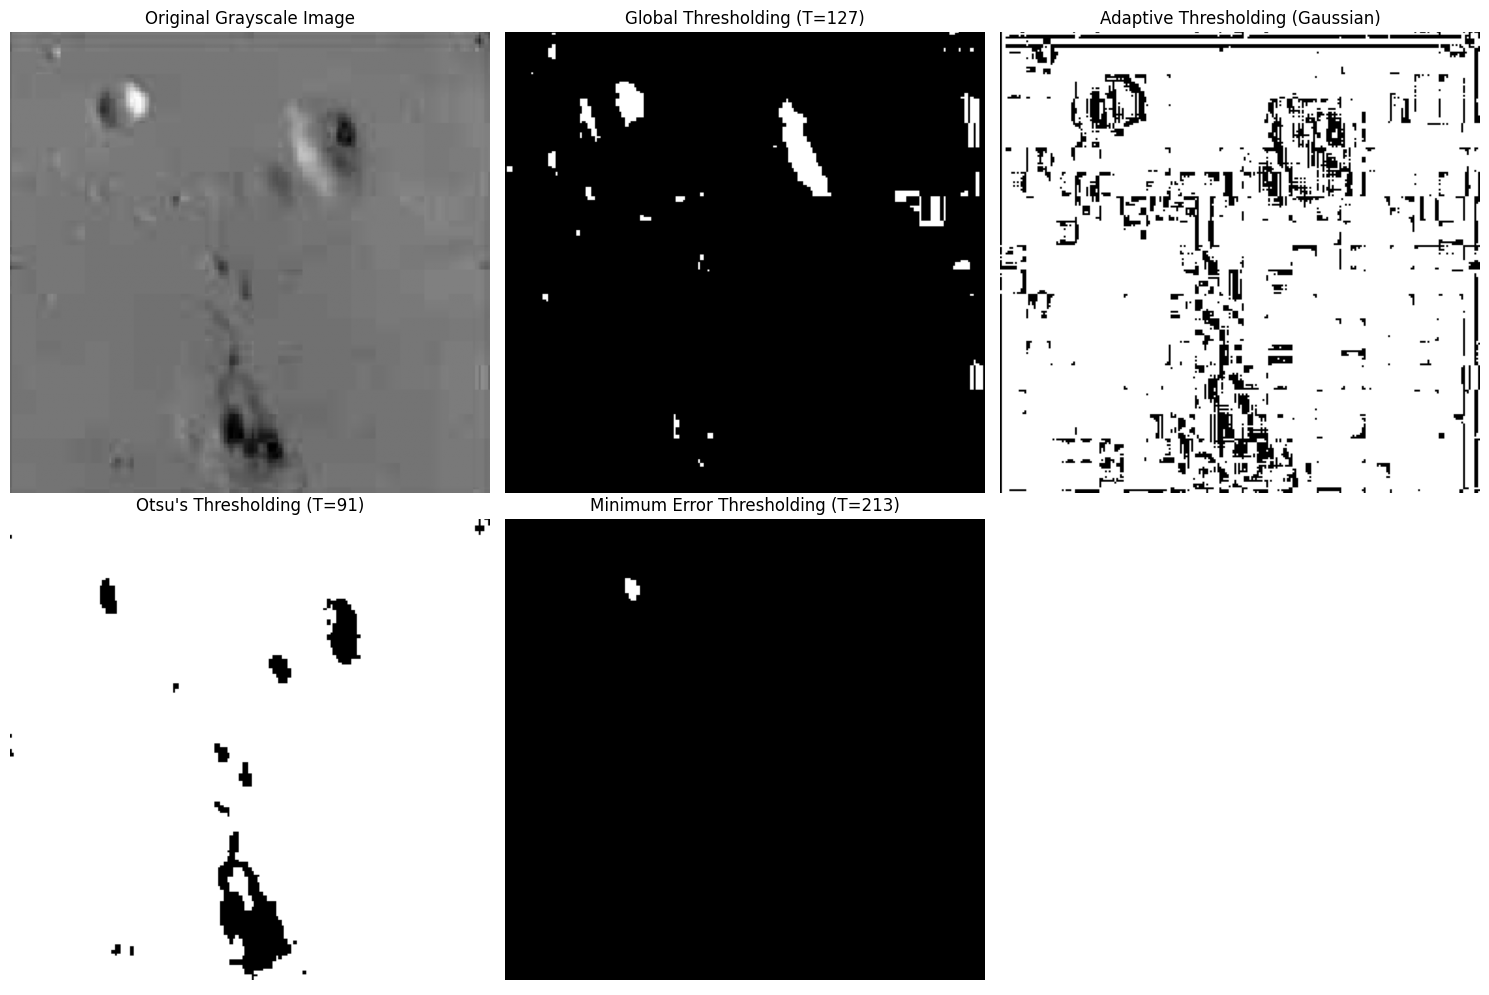

Visualized all thresholding results successfully.


In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
ax = axes.ravel()

ax[0].imshow(gray_image, cmap='gray')
ax[0].set_title('Original Grayscale Image')
ax[0].axis('off')

ax[1].imshow(global_thresholded_image, cmap='gray')
ax[1].set_title('Global Thresholding (T=127)')
ax[1].axis('off')

ax[2].imshow(adaptive_thresholded_image, cmap='gray')
ax[2].set_title('Adaptive Thresholding (Gaussian)')
ax[2].axis('off')

ax[3].imshow(otsu_thresholded_image, cmap='gray')
ax[3].set_title(f"Otsu's Thresholding (T={ret_otsu:.0f})")
ax[3].axis('off')

ax[4].imshow(min_error_thresholded_image, cmap='gray')
ax[4].set_title(f"Minimum Error Thresholding (T={ret_min_error:.0f})")
ax[4].axis('off')

ax[5].axis('off')

plt.tight_layout()
plt.show()
print("Visualized all thresholding results successfully.")

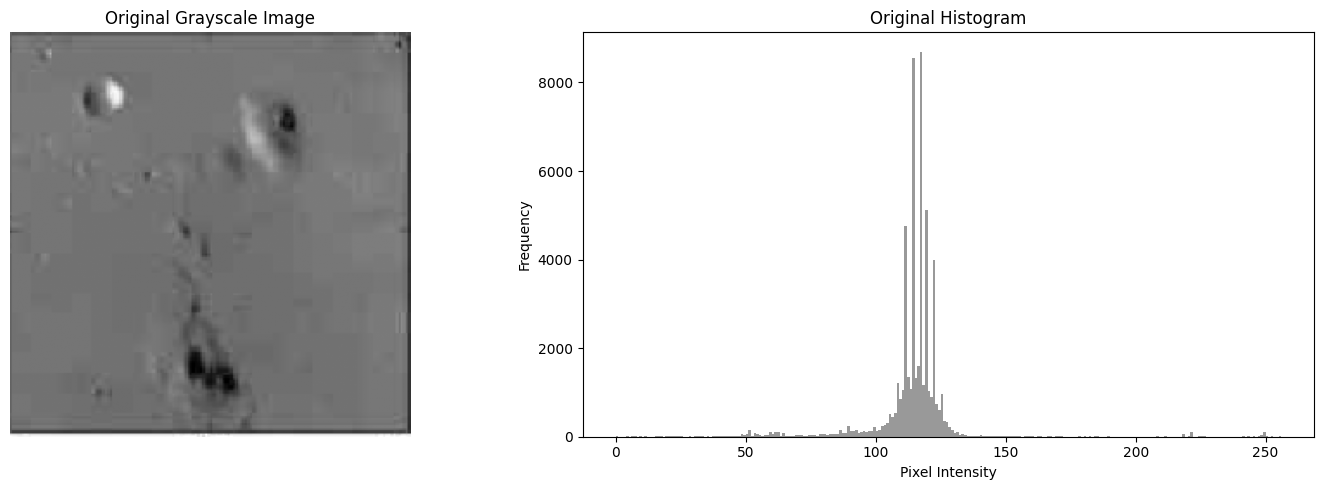

Original image and histogram baseline visualized successfully.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')

axes[1].hist(gray_image.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.8)
axes[1].set_title('Original Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Original image and histogram baseline visualized successfully.")

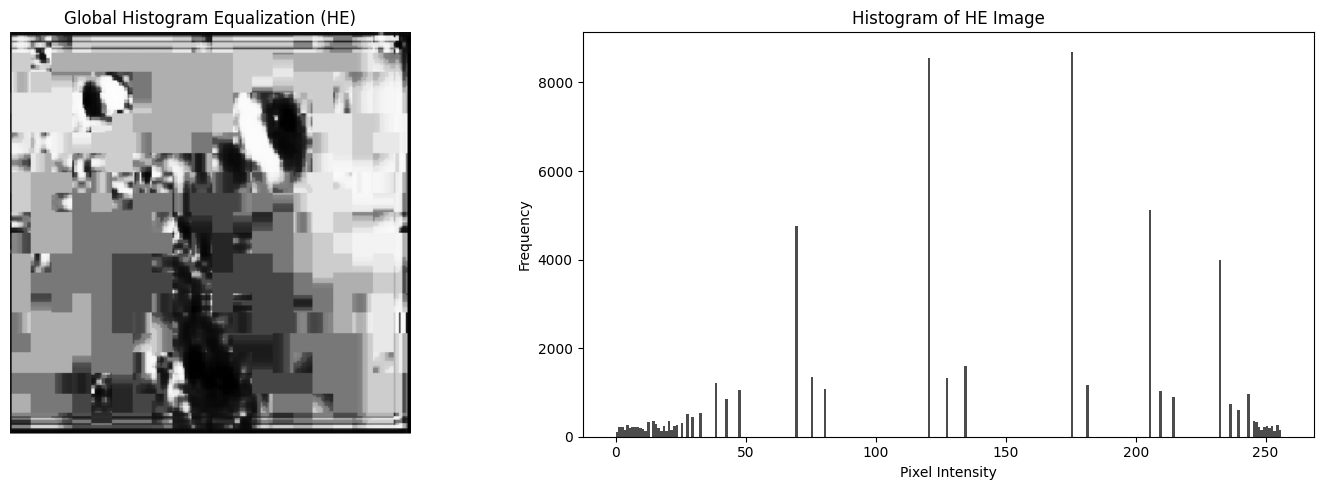

Mean Squared Error (MSE): 4658.68
Peak Signal-to-Noise Ratio (PSNR): 11.45 dB
Structural Similarity Index (SSIM): 0.4401


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

equalized_image = cv2.equalizeHist(gray_image)

he_mse = mse(gray_image, equalized_image)
he_psnr = psnr(gray_image, equalized_image)
he_ssim = ssim(gray_image, equalized_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(equalized_image, cmap='gray')
axes[0].set_title('Global Histogram Equalization (HE)')
axes[0].axis('off')

axes[1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
axes[1].set_title('Histogram of HE Image')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean Squared Error (MSE): {he_mse:.2f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {he_psnr:.2f} dB")
print(f"Structural Similarity Index (SSIM): {he_ssim:.4f}")

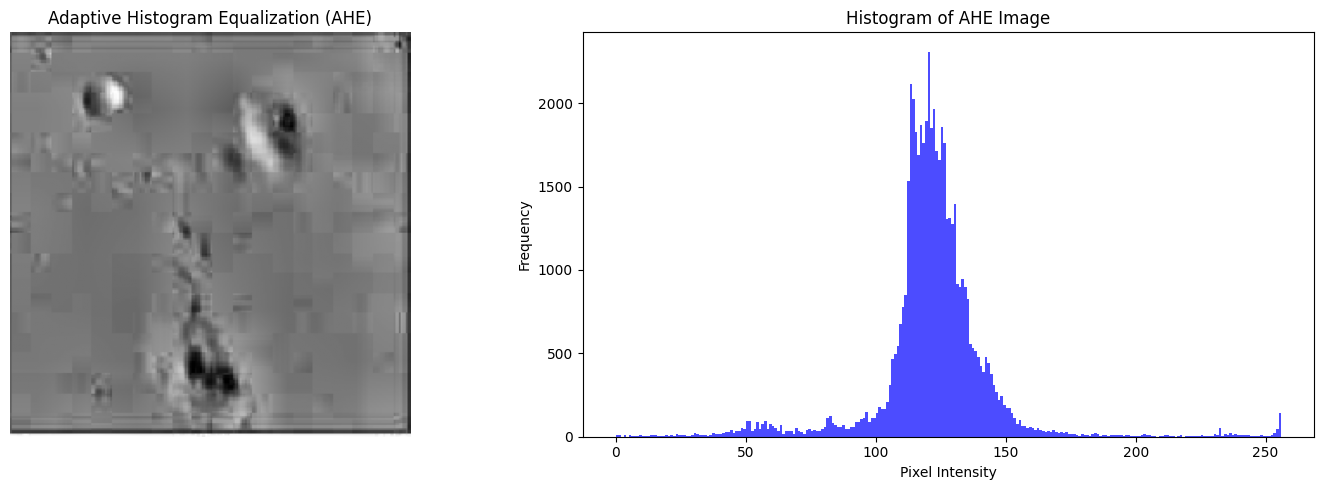

Mean Squared Error (MSE): 164.12
Peak Signal-to-Noise Ratio (PSNR): 25.98 dB
Structural Similarity Index (SSIM): 0.9135


In [ ]:
from skimage.exposure import equalize_adapthist
from skimage import img_as_ubyte
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt

ahe_image_float = equalize_adapthist(gray_image)
ahe_image = img_as_ubyte(ahe_image_float)

ahe_mse = mean_squared_error(gray_image, ahe_image)
ahe_psnr = peak_signal_noise_ratio(gray_image, ahe_image)
ahe_ssim = structural_similarity(gray_image, ahe_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(ahe_image, cmap='gray')
axes[0].set_title('Adaptive Histogram Equalization (AHE)')
axes[0].axis('off')

axes[1].hist(ahe_image.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axes[1].set_title('Histogram of AHE Image')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean Squared Error (MSE): {ahe_mse:.2f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {ahe_psnr:.2f} dB")
print(f"Structural Similarity Index (SSIM): {ahe_ssim:.4f}")

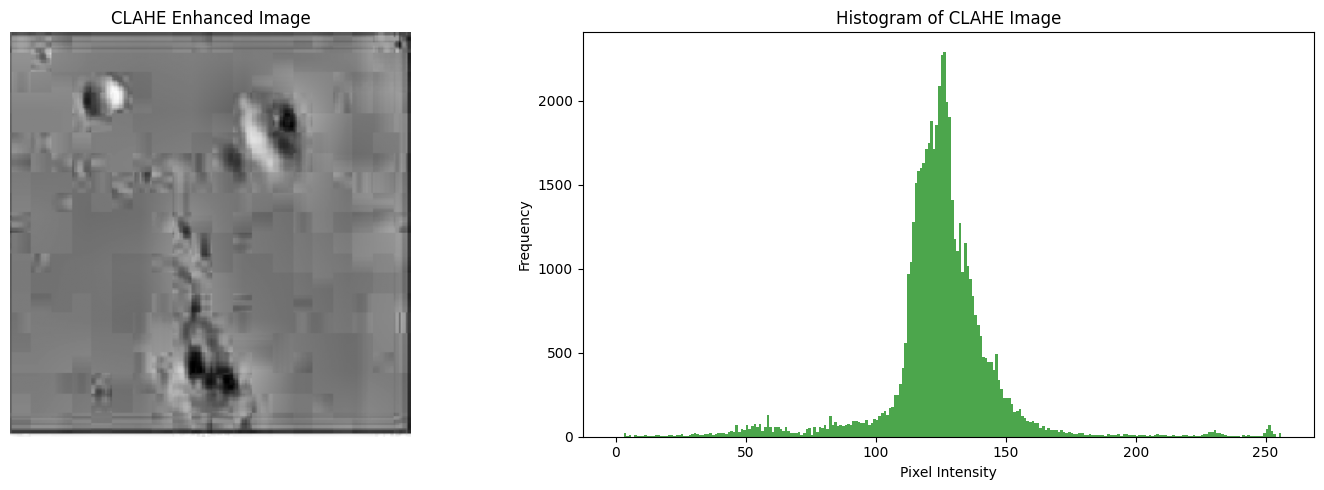

Mean Squared Error (MSE): 220.39
Peak Signal-to-Noise Ratio (PSNR): 24.70 dB
Structural Similarity Index (SSIM): 0.8917


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr, mean_squared_error as mse

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

clahe_image = clahe.apply(gray_image)

clahe_mse = mse(gray_image, clahe_image)
clahe_psnr = psnr(gray_image, clahe_image)
clahe_ssim = ssim(gray_image, clahe_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(clahe_image, cmap='gray')
axes[0].set_title('CLAHE Enhanced Image')
axes[0].axis('off')

axes[1].hist(clahe_image.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axes[1].set_title('Histogram of CLAHE Image')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean Squared Error (MSE): {clahe_mse:.2f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {clahe_psnr:.2f} dB")
print(f"Structural Similarity Index (SSIM): {clahe_ssim:.4f}")